In [1]:
# 필요한 라이브러리 가져오기
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# MNIST 데이터 로드
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 데이터 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

# 레이블 원-핫 인코딩
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 데이터 크기 확인
print('훈련 데이터 크기 : ', X_train.shape)
print('테스트 데이터 크기 : ', X_test.shape)

# 원-핫 인코딩 결과 확인
print('훈련 데이터 레이블 (원-핫 인코딩 전) : ', np.argmax(y_train[:5], axis=1))


훈련 데이터 크기 :  (60000, 28, 28)
테스트 데이터 크기 :  (10000, 28, 28)
훈련 데이터 레이블 (원-핫 인코딩 전) :  [5 0 4 1 9]


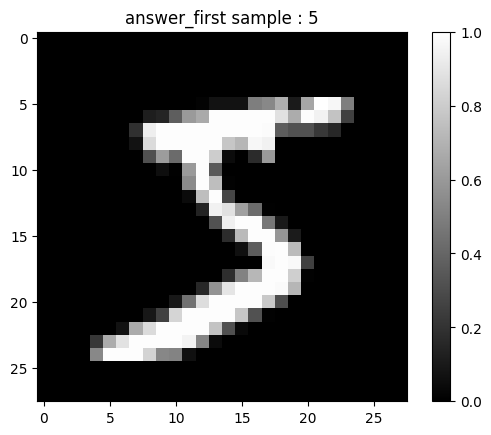

In [3]:
# 훈련 데이터의 첫 번째 샘플 시각화
plt.imshow(X_train[0], cmap='gray')  # 흑백 이미지로 표시
plt.title(f"answer_first sample : {np.argmax(y_train[0])}")  # 첫 번째 샘플의 레이블
plt.colorbar()  # 컬러바 추가
plt.show()  # 이미지 출력

In [4]:
# 2단계 : 모델 설계

model = Sequential([
    Flatten(input_shape=(28,28)),  # 28*28 이미지를 1차원으로 펼침 / 784개의 데이터 입력 => 28*28개의 데이터로 압축
    Dense(128,activation='relu'),  #은닉층 : 뉴런 128개
    Dense(64,activation='relu'),   # 은닉층 : 뉴런 64개
    Dense(10,activation='softmax') # 출력층 : 10개의 숫자 클래스
])
print('모델 설계 완료!')
model.summary()

모델 설계 완료!


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 3단계 : 모델 컴파일

model.compile(
    optimizer = 'adam',                # 옵티마이저
    loss = 'categorical_crossentropy', # 손실 함수
    metrics=['accuracy']               # 평가 지표
)
print('모델 컴파일 완료!')

모델 컴파일 완료!


In [12]:
# 4단계 : 모델 학습

history = model.fit(
    X_train,y_train,      # 훈련 데이터와 정답
    epochs=5,             # 학습 반복 횟수
    batch_size = 32,      # 한 번에 처리할 데이터 크기
    validation_split=0.2  # 20% 데이터를 검증용으로 사용
)
print('모델 학습 완료!')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9965 - loss: 0.0098 - val_accuracy: 0.9762 - val_loss: 0.1234
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9967 - loss: 0.0094 - val_accuracy: 0.9770 - val_loss: 0.1391
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9973 - loss: 0.0086 - val_accuracy: 0.9770 - val_loss: 0.1295
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9973 - loss: 0.0090 - val_accuracy: 0.9732 - val_loss: 0.1661
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9952 - loss: 0.0134 - val_accuracy: 0.9774 - val_loss: 0.1333
모델 학습 완료!


In [13]:
# 4단계 : 모델 학습2

history = model.fit(
    X_train,y_train,      # 훈련 데이터와 정답
    epochs=10,             # 학습 반복 횟수
    batch_size = 32,      # 한 번에 처리할 데이터 크기
    validation_split=0.2  # 20% 데이터를 검증용으로 사용
)
print('모델 학습 완료!')

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9985 - loss: 0.0044 - val_accuracy: 0.9701 - val_loss: 0.1796
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9957 - loss: 0.0137 - val_accuracy: 0.9778 - val_loss: 0.1388
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9983 - loss: 0.0056 - val_accuracy: 0.9743 - val_loss: 0.1794
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9960 - loss: 0.0124 - val_accuracy: 0.9759 - val_loss: 0.1838
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9980 - loss: 0.0060 - val_accuracy: 0.9758 - val_loss: 0.1743
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9987 - loss: 0.0043 - val_accuracy: 0.9676 - val_loss: 0.2171
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9970 - loss: 0.0089 - val_accuracy: 0.9739 - val_loss: 0.1925
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9981 - loss: 0.0063

In [19]:
# 5단계 : 모델 평가
loss , accuracy = model.evaluate(X_test,y_test)
print(f'테스트 손실:{loss:.4f}')
print(f'테스트 정확도 : {accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9705 - loss: 0.1861
테스트 손실:0.1554
테스트 정확도 : 0.9749


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
image 1 predict : 7 ( prop : 1.000000)
image 2 predict : 2 ( prop : 1.000000)
image 3 predict : 1 ( prop : 0.999999)
image 4 predict : 0 ( prop : 1.000000)
image 5 predict : 4 ( prop : 0.999999)


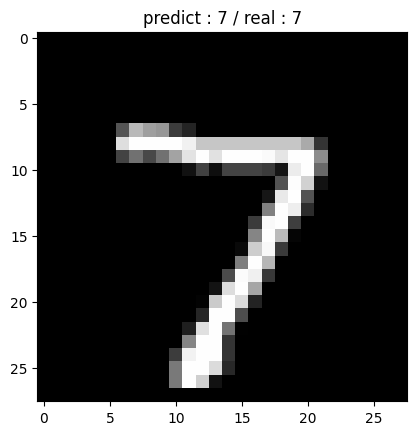

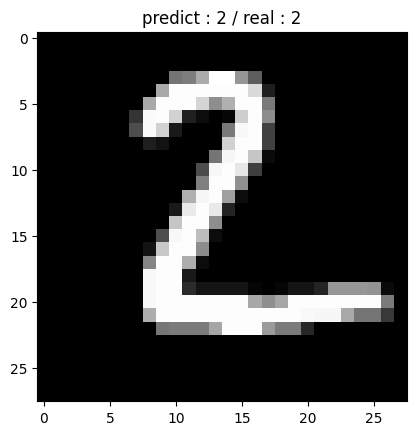

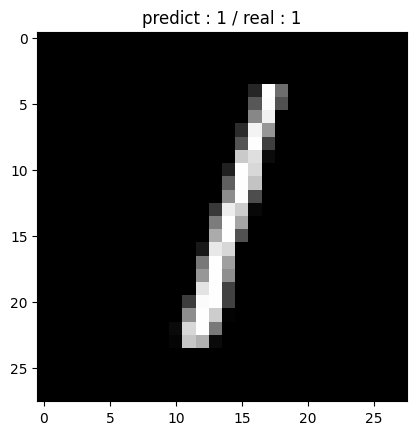

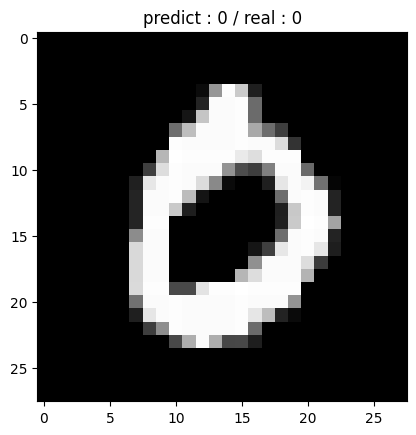

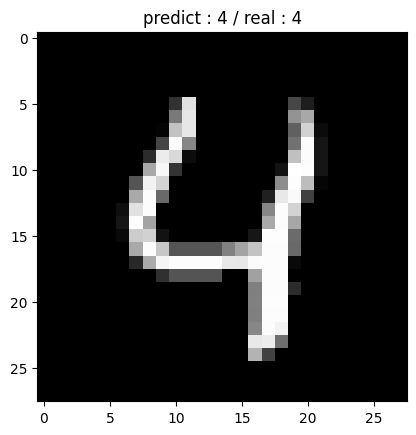

In [20]:
# 6단계 : 예측
predictions = model.predict(X_test[:5])

for i , prediction in enumerate(predictions):
  print(f'image {i+1} predict : {np.argmax(prediction)} ( prop : {max(prediction):2f})')

# 테스트 데이터의 첫 번째 샘플 시각화와 예측값 비교

for i in range(5):
  plt.imshow(X_test[i],cmap='gray')
  plt.title(f'predict : {np.argmax(predictions[i])} / real : {np.argmax(y_test[i])}')
  plt.show()